# Taller: Boosting en salud — AdaBoost y XGBoost
## 1. Introducción

El Boosting es una técnica de ensemble learning que combina múltiples clasificadores débiles (modelos simples, como árboles pequeños) para crear un modelo fuerte con alto rendimiento. En medicina, Boosting es útil para tareas donde se requiere alta sensibilidad y especificidad, como en la detección temprana de cáncer o la predicción de riesgo cardiovascular.

En este taller exploraremos dos de los algoritmos más utilizados:

* AdaBoost (Adaptive Boosting): ajusta modelos secuenciales, poniendo mayor peso en los errores de iteraciones previas.

* XGBoost (Extreme Gradient Boosting): una versión más eficiente y regularizada, ampliamente usada en competencias y aplicaciones reales de salud.

Trabajaremos con el dataset de cáncer de mama (Breast Cancer) para clasificación binaria, y con el dataset de Diabetes para regresión.


## 2. Objetivos

1. **Aplicar AdaBoost y XGBoost** en un dataset biomédico.
2. **Comparar desempeño** frente a modelos simples (árboles de decisión).
3. **Visualizar la importancia de variables clínicas** en las predicciones.
4. **Evaluar resultados con métricas adecuadas** (accuracy, AUC-ROC, RMSE según el caso).
5. **Analizar implicancias clínicas** de usar modelos de boosting en diagnóstico y pronóstico médico.

## 3. Importar librerías y datos




In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Metricas y utilidades
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix

# Regresión
from sklearn.ensemble import AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


# Modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
import xgboost as xgb


## 4. Dataset: Cáncer de mama

El **Breast Cancer Dataset** permite clasificar tumores como **benignos** o **malignos**.

* **Instancias:** 569
* **Variables:** 30 (características de núcleos celulares)
* **Variable objetivo:** `Diagnosis` (0=maligno, 1=benigno)


#### **Ejercicio 1** 

1. Cargar el dataset.
2. Dividir en train (80%) y test (20%).
3. Entrenar un **DecisionTreeClassifier** como modelo base con `max_depth=2` y `random_state=42`.
4. Evaluar con *accuracy* y *AUC-ROC*. Generar curva ROC.
5. Generar matriz de confusión.
6. Responder:
   * ¿El árbol simple logra una buena clasificación?


Accuracy: 0.8947368421052632
AUC-ROC: 0.9067460317460316


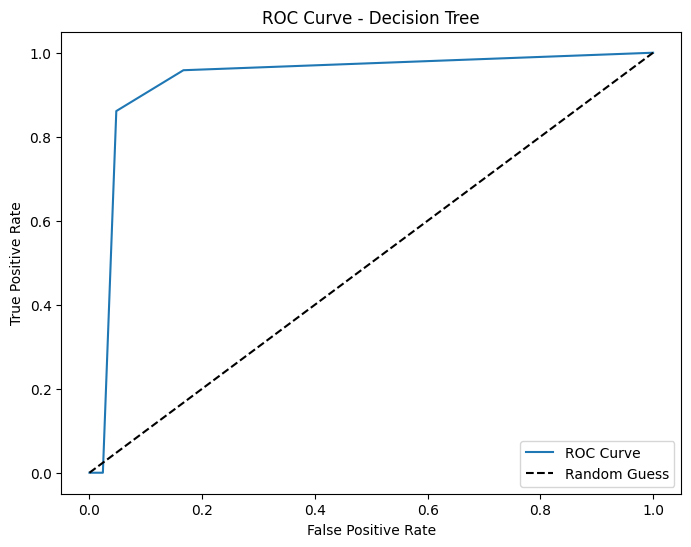

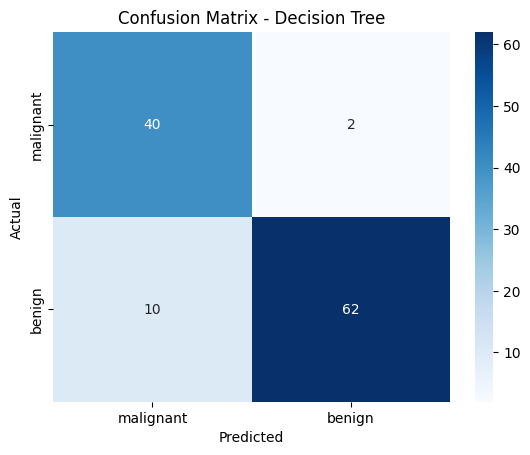

In [95]:
# <CODE> 1. Cargar dataset
bc = load_breast_cancer()
X = pd.DataFrame(bc.data, columns=bc.feature_names)
y = pd.Series(bc.target, name="target")

# <CODE> 2. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# <CODE>3. Árbol de decisión baseline
tree = DecisionTreeClassifier(max_depth=2, random_state=42)
tree.fit(X_train, y_train)

# <CODE>  4. Evaluación y curva ROC
y_pred = tree.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("AUC-ROC:", roc_auc_score(y_test, y_pred))

y_prob = tree.predict_proba(X_test)[:, 1]
fpr_arbol, tpr_arbol, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr_arbol, tpr_arbol, label="ROC Curve")
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()
plt.show()

# 5. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.show()



#### **Ejercicio 2** 

1. Entrenar un **AdaBoostClassifier** con árboles (`DecisionTreeClassifier`) como base.
2. Evaluar desempeño en test con *accuracy* y *AUC-ROC*.
3. Comparar contra el árbol anterior, ploteando las curvas ROC en un mismo gráfico.
4. Graficar **importancia de variables** según AdaBoost.
5. Generar matriz de confusión.
6. Responder:
   * ¿Mejora AdaBoost respecto al árbol simple?
   * ¿Qué variables son más importantes según AdaBoost?


Accuracy AdaBoost: 0.9736842105263158
AUC-ROC AdaBoost: 0.9642857142857143


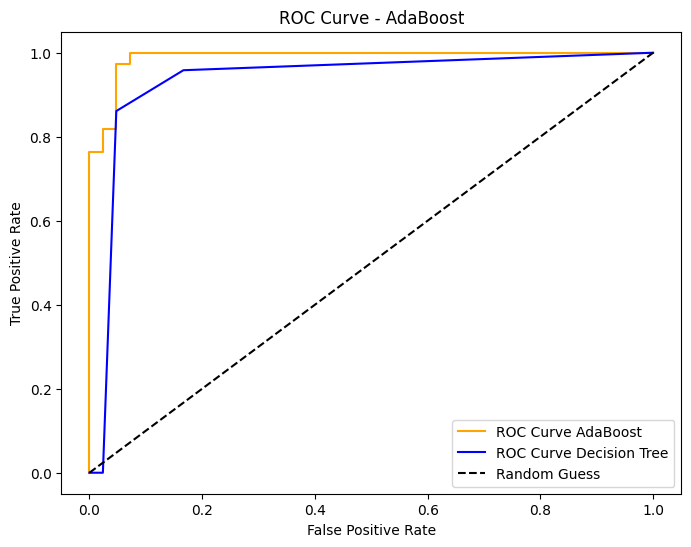

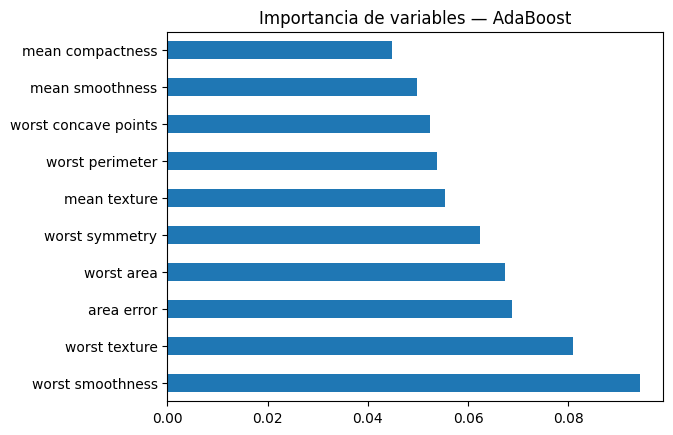

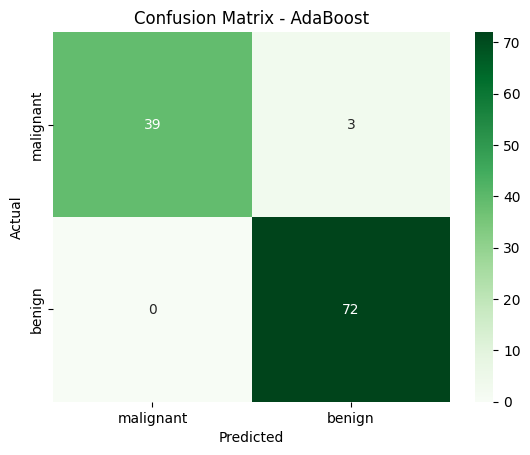

In [96]:

# <CODE> 1. AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=2),
    n_estimators=100,
    random_state=42
)
ada.fit(X_train, y_train)

# <CODE> 2. Evaluación 
y_pred_ada = ada.predict(X_test)

print("Accuracy AdaBoost:", accuracy_score(y_test, y_pred_ada))
print("AUC-ROC AdaBoost:", roc_auc_score(y_test, y_pred_ada))

# <CODE> 3. Curva ROC comparativa
y_prob_ada = ada.predict_proba(X_test)[:, 1]
fpr_ada, tpr_ada, _ = roc_curve(y_test, y_prob_ada)
plt.figure(figsize=(8, 6))
plt.plot(fpr_ada, tpr_ada, label="ROC Curve AdaBoost", color='orange')
plt.plot(fpr_arbol, tpr_arbol, label="ROC Curve Decision Tree", color='blue')
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AdaBoost")
plt.legend()
plt.show()

# <CODE> 4. Importancia de variables
importances = pd.Series(ada.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Importancia de variables — AdaBoost")
plt.show()

# <CODE> 5. Matriz de confusión
cm_ada = confusion_matrix(y_test, y_pred_ada)
sns.heatmap(cm_ada, annot=True, fmt='d', cmap='Greens', xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - AdaBoost')
plt.show()




#### **Ejercicio 3** 

1. Entrenar un **XGBClassifier**.
2. Evaluar desempeño en test con *accuracy* y *AUC-ROC*.
3. Comparar desempeño con AdaBoost y el árbol de decisión antes creado, mediante el grafico de curvas ROC.
4. Graficar **importancia de variables** según XGBoost.
5. Generar matriz de confusión.
6. Responder:
    * ¿Cómo se compara XGBoost con AdaBoost y el árbol simple?
    * ¿Qué variables son más importantes según XGBoost? ¿Son similares a las de AdaBoost?



/home/carlos/anaconda3/envs/uci/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:37:13] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy XGBoost: 0.956140350877193
AUC-ROC XGBoost: 0.945436507936508


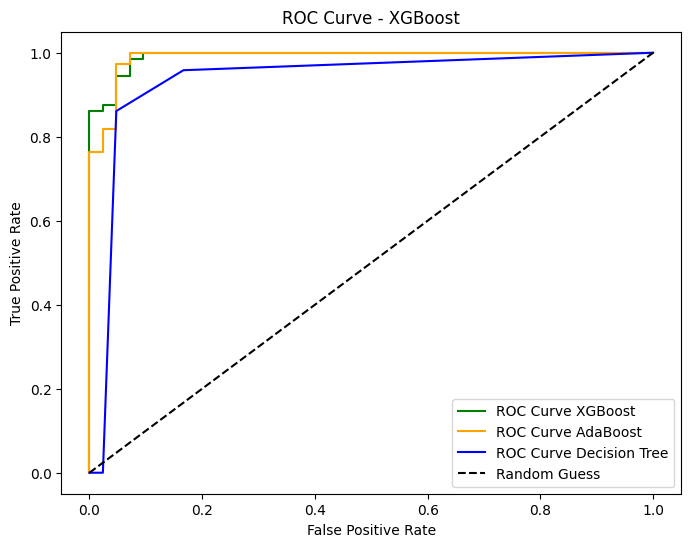

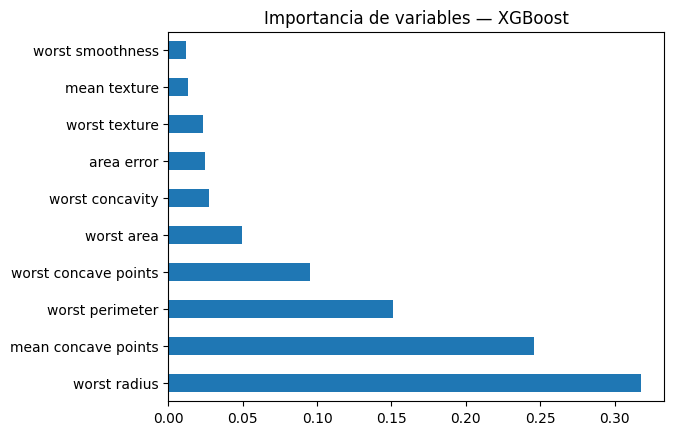

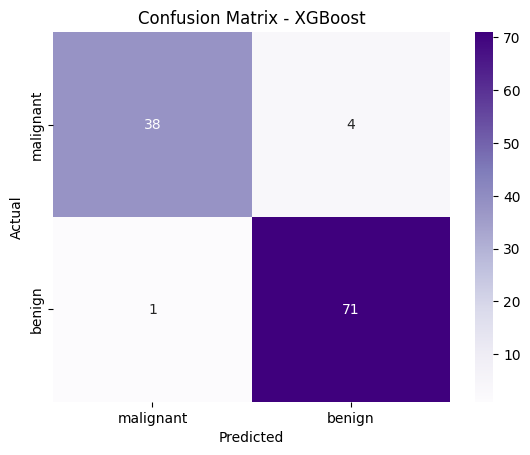

In [97]:

# <CODE> 1. Entrenar XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=1,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)

# <CODE> 2. Evaluar desempeño
y_pred_xgb = xgb_model.predict(X_test)
print("Accuracy XGBoost:", accuracy_score(y_test, y_pred_xgb))
print("AUC-ROC XGBoost:", roc_auc_score(y_test, y_pred_xgb))

# <CODE> 3. Comparar curvas ROC
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label="ROC Curve XGBoost", color='green')
plt.plot(fpr_ada, tpr_ada, label="ROC Curve AdaBoost", color='orange')
plt.plot(fpr_arbol, tpr_arbol, label="ROC Curve Decision Tree", color='blue')
plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - XGBoost")
plt.legend()
plt.show()  

# <CODE> 4. Importancia de variables
importances_xgb = pd.Series(xgb_model.feature_importances_, index=X.columns)
importances_xgb.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Importancia de variables — XGBoost")
plt.show()

# <CODE> 5. Matriz de confusión
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', xticklabels=bc.target_names, yticklabels=bc.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - XGBoost')
plt.show()




#### **Ejercicio 4** 

1. Ajusta el **umbral de decisión** en AdaBoost y XGBoost (por defecto es 0.5).
2. Calcula sensibilidad y especificidad para umbrales de 0.3, 0.4, 0.5 y 0.7.
3. Responde:
   * ¿Qué umbral favorece la **detección temprana de cáncer (sensibilidad alta)**?
   * ¿Qué umbral minimiza los **falsos positivos**?
   * ¿Qué escenario clínico justificaría cada elección?



In [98]:
# <CODE> 1. Dataset
bc = load_breast_cancer()
X = pd.DataFrame(bc.data, columns=bc.feature_names)
y = pd.Series(bc.target, name="target")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# <CODE> 2. AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=200,
    random_state=42
)
ada.fit(X_train, y_train)
probs_ada = ada.predict_proba(X_test)[:,1]

# <CODE> 3. XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.1,
    use_label_encoder=False, eval_metric="logloss", random_state=42
)
xgb_model.fit(X_train, y_train)
probs_xgb = xgb_model.predict_proba(X_test)[:,1]

# Función auxiliar para calcular sensibilidad y especificidad
def eval_threshold(y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    sensibilidad = tp / (tp + fn)
    especificidad = tn / (tn + fp)
    return sensibilidad, especificidad

# <CODE> 4. Evaluación para distintos umbrales
thresholds = [0.3,0.4,  0.5, 0.7]
print("=== AdaBoost ===")
for t in thresholds:
    sens, esp = eval_threshold(y_test, probs_ada, t)
    print(f"Umbral {t:.1f} -> Sensibilidad={sens:.3f}, Especificidad={esp:.3f}")

print("\n=== XGBoost ===")
for t in thresholds:
    sens, esp = eval_threshold(y_test, probs_xgb, t)
    print(f"Umbral {t:.1f} -> Sensibilidad={sens:.3f}, Especificidad={esp:.3f}")




/home/carlos/anaconda3/envs/uci/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [00:37:14] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


=== AdaBoost ===
Umbral 0.3 -> Sensibilidad=1.000, Especificidad=0.571
Umbral 0.4 -> Sensibilidad=1.000, Especificidad=0.786
Umbral 0.5 -> Sensibilidad=1.000, Especificidad=0.905
Umbral 0.7 -> Sensibilidad=0.292, Especificidad=1.000

=== XGBoost ===
Umbral 0.3 -> Sensibilidad=1.000, Especificidad=0.905
Umbral 0.4 -> Sensibilidad=1.000, Especificidad=0.905
Umbral 0.5 -> Sensibilidad=0.972, Especificidad=0.905
Umbral 0.7 -> Sensibilidad=0.958, Especificidad=0.905


## 5. Dataset Diabetes

El dataset Diabetes de scikit-learn contiene información clínica de 442 pacientes con 10 variables predictoras estandarizadas:
* Edad 
* sexo
* IMC (bmi)
* presión arterial (bp)
* 6 medidas séricas (s1–s6).

La variable objetivo (target) corresponde a una medida continua de la progresión de la enfermedad un año después de la toma de datos iniciales.

#### **Ejercicio 5** 

1. Cargar el dataset de diabetes.
2. Entrenar un modelo de regresión base (`DecisionTreeRegressor`) para predecir la progresión de la enfermedad.
3. Entrenar `AdaBoostRegressor` y `XGBRegressor`.
4. Evalúa con RMSE (error promedio) y R² (qué porcentaje de la variabilidad explica el modelo)
5. Responder:
   * ¿Qué modelo tiene mejor capacidad predictiva?
   * ¿Qué tan útiles son estas predicciones en un contexto clínico?


In [99]:
# <CODE> 1. Cargar dataset
db = load_diabetes()
X = pd.DataFrame(db.data, columns=db.feature_names)
y = pd.Series(db.target, name="progression")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# <CODE> 2. Baseline con árbol
tree_reg = DecisionTreeRegressor(max_depth=2, random_state=42)
tree_reg.fit(X_train, y_train)
y_pred_tree = tree_reg.predict(X_test)
print("Baseline Árbol RMSE:", mean_squared_error(y_test, y_pred_tree))
print("Baseline Árbol R2:", r2_score(y_test, y_pred_tree))

# <CODE> 3. AdaBoost Regressor
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=2),
    n_estimators=100,
    random_state=42
)
ada_reg.fit(X_train, y_train)
y_pred_ada = ada_reg.predict(X_test)
print("AdaBoost RMSE:", mean_squared_error(y_test, y_pred_ada))
print("AdaBoost R2:", r2_score(y_test, y_pred_ada))

# <CODE> 4. XGBRegressor
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=2, random_state=42)
xgb_reg.fit(X_train, y_train)
y_pred_xgb = xgb_reg.predict(X_test)
print("XGBoost RMSE:", mean_squared_error(y_test, y_pred_xgb))
print("XGBoost R2:", r2_score(y_test, y_pred_xgb))

Baseline Árbol RMSE: 3735.4996177389003
Baseline Árbol R2: 0.2949428791304852
AdaBoost RMSE: 2930.356667767177
AdaBoost R2: 0.44690963814171036
XGBoost RMSE: 2869.673884441448
XGBoost R2: 0.45836321406896063


#### **Ejercicio 6** 
1. Muestra la importancia de variables en XGBoost.
2. Identifica las 3 más influyentes.
3. Responde:
    * ¿Estas variables son conocidas factores de riesgo en diabetes?
    * ¿Qué significa clínicamente que ciertas variables dominen la predicción?

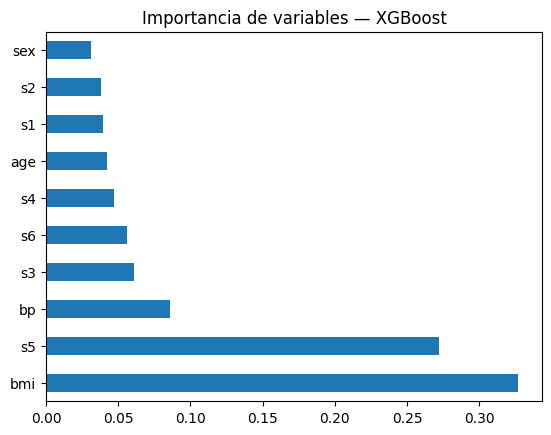

In [100]:
# <CODE>
importances = pd.Series(xgb_reg.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind="barh")
plt.title("Importancia de variables — XGBoost")
plt.show()
